# Overview of Deep Learning

## Learning Objectives
- Understand the basic concepts of deep learning.
- Get hands on building simple neural network.

## Introduction
Deep Learning is a subfield of machine learning that consists of algorithms that mimic how a human or animal brain functions in terms of neurons, perceptrons and all the like.The computer does this by exploring and discovering hidden patterns and correlations in raw data using algorithms. This enables systems to create data clusters and make predictions with great accuracy. 

Deep learning has ability to ingest and process unstructured data such as text and images. It goes beyond machine learning to eliminate some pre-processing tasks

Neural Networks(NN) are machine learning models developed to replicate or mimic the behaviour of neural networks found in human and animal brains. They are also known as Artificial Neural Networks (ANN) or Simulated Neural Networks (SNN). Such networks can be classified based on topologies, data flow, neurons, layers and filters

The neural network without any activation function in any of its layers is called a linear neural network.
The neural network which has action functions like relu, sigmoid or tanh in any of its layer or even in more than one layer is called non-linear neural network.

## Neural Network Types

- Multilayer Perceptrons or Feed-forward Networks (MLP)
- Convolutional Neural Networks (CNN)
- Recurrent Neural Networks (RNN)
- Long Short-Term Memory Networks (LSTM)
- Gated Recurrent Units (GRU)
- Radial Basis Function Networks (RBFN)
- Self-Organizing Maps (SOM)
- Deep Belief Networks (DBN)
- Generative Adversarial Networks (GAN)
- Autoencoders (AE)
- Siamese Neural Networks
- Capsule Networks (CapsNet)
- Transformer Networks
- Spiking Neural Networks (SNN)

End-to-end neural network example

In [5]:
import numpy as np

# --- 1. The Problem: XOR ---
# We will teach a network to solve the XOR problem.
# X = input data, y = target output
#   X   |   y
# ----------------
# [0,0] | [0]
# [0,1] | [1]
# [1,0] | [1]
# [1,1] | [0]

X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

# --- 2. The Architecture ---
# We'll use a very simple network:
# - Input Layer: 2 neurons (for the 2 inputs)
# - Hidden Layer: 3 neurons
# - Output Layer: 1 neuron (for the single output value)

input_neurons = 2
hidden_neurons = 3
output_neurons = 1

# --- 3. Activation Function ---
# We'll use the sigmoid function, which squashes values between 0 and 1.
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# We also need the derivative of sigmoid for backpropagation.
def sigmoid_derivative(x):
    return x * (1 - x)

# --- 4. Initialize Weights and Biases ---
# Weights and biases are the "knobs" the network will "turn" during training to learn.
# We initialize them with random values.
np.random.seed(42) # for reproducibility
weights_hidden = np.random.rand(input_neurons, hidden_neurons)
biases_hidden = np.random.rand(1, hidden_neurons)
weights_output = np.random.rand(hidden_neurons, output_neurons)
biases_output = np.random.rand(1, output_neurons)

# --- 5. The Training Loop ---
# This is where the network learns.
learning_rate = 1.0
epochs = 10000

for epoch in range(epochs):
    
    # --- FORWARD PASS ---
    # This is the process of passing the input through the network to get a prediction.
    
    # Step 1: Calculate hidden layer output
    hidden_layer_input = np.dot(X, weights_hidden) + biases_hidden
    hidden_layer_output = sigmoid(hidden_layer_input)
    
    # Step 2: Calculate output layer output (the final prediction)
    output_layer_input = np.dot(hidden_layer_output, weights_output) + biases_output
    predicted_output = sigmoid(output_layer_input)
    
    # --- BACKWARD PASS (BACKPROPAGATION) ---
    # This is the process of figuring out how wrong the prediction was and
    # adjusting the weights and biases to do better next time.
    
    # Step 3: Calculate the error
    # How far off was our prediction from the actual target?
    error = y - predicted_output
    
    # Step 4: Calculate the "delta" (gradient) for the output layer.
    # This uses the chain rule: error * derivative_of_activation_function
    d_predicted_output = error * sigmoid_derivative(predicted_output)
    
    # Step 5: Calculate the error for the hidden layer.
    # How much did the hidden layer contribute to the output error?
    error_hidden_layer = d_predicted_output.dot(weights_output.T)
    
    # Step 6: Calculate the "delta" (gradient) for the hidden layer.
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_layer_output)
    
    # --- UPDATE WEIGHTS AND BIASES ---
    # Now we adjust the "knobs" based on the gradients we calculated.
    
    # Step 7: Update output layer's weights and biases
    weights_output += hidden_layer_output.T.dot(d_predicted_output) * learning_rate
    biases_output += np.sum(d_predicted_output, axis=0, keepdims=True) * learning_rate
    
    # Step 8: Update hidden layer's weights and biases
    weights_hidden += X.T.dot(d_hidden_layer) * learning_rate
    biases_hidden += np.sum(d_hidden_layer, axis=0, keepdims=True) * learning_rate

    # (Optional) Print the loss every 1000 epochs to see progress
    if epoch % 1000 == 0:
        loss = np.mean(np.abs(error))
        print(f'Epoch: {epoch}, Loss: {loss:.4f}')

# --- 6. Final Prediction ---
print("\n--- Training Finished ---")
print("Final predictions after training:")
print(predicted_output.round())

Epoch: 0, Loss: 0.4990
Epoch: 1000, Loss: 0.0803
Epoch: 2000, Loss: 0.0375
Epoch: 3000, Loss: 0.0275
Epoch: 4000, Loss: 0.0226
Epoch: 5000, Loss: 0.0196
Epoch: 6000, Loss: 0.0175
Epoch: 7000, Loss: 0.0159
Epoch: 8000, Loss: 0.0147
Epoch: 9000, Loss: 0.0137

--- Training Finished ---
Final predictions after training:
[[0.]
 [1.]
 [1.]
 [0.]]


A more robust example of neural network

--- Starting Training ---
Epoch: 0, Loss: 0.6969, Accuracy: 0.4938
Epoch: 1000, Loss: 0.0102, Accuracy: 1.0000
Epoch: 2000, Loss: 0.0060, Accuracy: 1.0000
Epoch: 3000, Loss: 0.0044, Accuracy: 1.0000
Epoch: 4000, Loss: 0.0036, Accuracy: 1.0000
Epoch: 5000, Loss: 0.0030, Accuracy: 1.0000
Epoch: 6000, Loss: 0.0026, Accuracy: 1.0000
Epoch: 7000, Loss: 0.0023, Accuracy: 1.0000
Epoch: 8000, Loss: 0.0021, Accuracy: 1.0000
Epoch: 9000, Loss: 0.0019, Accuracy: 1.0000
Epoch: 10000, Loss: 0.0018, Accuracy: 1.0000
--- Training Finished ---

--- Evaluating on Test Data ---
Test Loss: 0.0363, Test Accuracy: 0.9800

--- Performing Inference on a New Data Point ---
Data Point: [0.   0.75]
Prediction Probabilities: [0.46554532 0.53445468]
Predicted Class: 1 (0=Outer Circle, 1=Inner Circle)


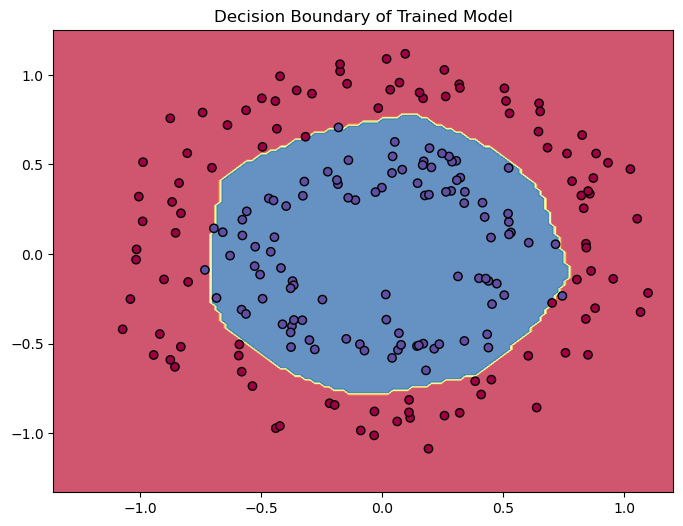

In [6]:
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# --- 1. Data Processing ---
# Generate a non-linear dataset using scikit-learn's make_circles.
# This data is not linearly separable, so a neural network is required.
X, y = make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. Model and Component Definitions ---

# (Reusing and extending our classes from the previous example)
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.1 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
        
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases
        
    def backward(self, dvalues):
        # Gradients on parameters
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        # Gradient on values
        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)
        
    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] = 0

class Activation_Softmax:
    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        self.output = exp_values / np.sum(exp_values, axis=1, keepdims=True)

class Loss_CategoricalCrossentropy:
    def forward(self, y_pred, y_true):
        samples = len(y_pred)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        
        # Handle categorical labels (e.g., [0, 1, 0]) or sparse labels (e.g., 1)
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[range(samples), y_true]
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(y_pred_clipped * y_true, axis=1)
            
        return -np.log(correct_confidences)

    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        labels = len(dvalues[0])
        
        # If labels are sparse, turn them into one-hot vector
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]
            
        self.dinputs = -y_true / dvalues
        self.dinputs = self.dinputs / samples

# Optimizer to update weights and biases
class Optimizer_SGD:
    def __init__(self, learning_rate=1.0):
        self.learning_rate = learning_rate
        
    def update_params(self, layer):
        layer.weights += -self.learning_rate * layer.dweights
        layer.biases += -self.learning_rate * layer.dbiases

# --- 3. Model Initialization ---
# Let's build a simple network: Dense(2 -> 64) -> ReLU -> Dense(64 -> 2) -> Softmax
dense1 = Layer_Dense(2, 64)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(64, 2)
softmax_activation = Activation_Softmax()
loss_function = Loss_CategoricalCrossentropy()
optimizer = Optimizer_SGD(learning_rate=0.8)

# --- 4. Model Training ---
EPOCHS = 10001
print("--- Starting Training ---")

for epoch in range(EPOCHS):
    # --- Forward Pass ---
    dense1.forward(X_train)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    softmax_activation.forward(dense2.output)
    
    # --- Calculate Loss ---
    data_loss = np.mean(loss_function.forward(softmax_activation.output, y_train))
    
    # --- Backward Pass (Backpropagation) ---
    # A simplified backward pass for Softmax + Cross-Entropy
    # This is a common optimization for stability and speed.
    dvalues = softmax_activation.output.copy()
    dvalues[range(len(X_train)), y_train] -= 1
    dvalues = dvalues / len(X_train)
    
    dense2.backward(dvalues)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)
    
    # --- Update Weights and Biases ---
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    
    if epoch % 1000 == 0:
        predictions = np.argmax(softmax_activation.output, axis=1)
        accuracy = np.mean(predictions == y_train)
        print(f'Epoch: {epoch}, Loss: {data_loss:.4f}, Accuracy: {accuracy:.4f}')

print("--- Training Finished ---")

# --- 5. Model Evaluation ---
print("\n--- Evaluating on Test Data ---")
dense1.forward(X_test)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
softmax_activation.forward(dense2.output)

test_loss = np.mean(loss_function.forward(softmax_activation.output, y_test))
test_predictions = np.argmax(softmax_activation.output, axis=1)
test_accuracy = np.mean(test_predictions == y_test)

print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

# --- 6. Inference ---
print("\n--- Performing Inference on a New Data Point ---")
new_point = np.array([[0.0, 0.75]]) # A point inside the inner circle

dense1.forward(new_point)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
softmax_activation.forward(dense2.output)

prediction_probs = softmax_activation.output
predicted_class = np.argmax(prediction_probs)

print(f"Data Point: {new_point[0]}")
print(f"Prediction Probabilities: {prediction_probs[0]}")
print(f"Predicted Class: {predicted_class} (0=Outer Circle, 1=Inner Circle)")

# --- Optional: Visualize Decision Boundary ---
h = 0.02
x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_points = np.c_[xx.ravel(), yy.ravel()]

dense1.forward(grid_points)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
softmax_activation.forward(dense2.output)
Z = np.argmax(softmax_activation.output, axis=1)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.Spectral, edgecolors='k')
plt.title("Decision Boundary of Trained Model")
plt.show()


## Exercise
Research one breakthrough in deep learning and summarize its impact.

In [ ]:
# Your notes here

## Summary
- Deep learning history is marked by innovation and persistence.
- Key algorithms and hardware advances enable current successes.


## Further Reading
- [Deep Learning Timeline by MIT](https://deeplearning.mit.edu/)
- [History of Neural Networks](https://www.nature.com/articles/nature14539)
